# Partial Correlation Analysis — Controlling for Halo Mass

**Purpose:** Test whether the correlation between galaxy redness (u−r) / group red fraction and 
environmental measures survives once halo mass is controlled for.

**Method:** Partial correlation via residualisation.
1. Regress `uminusr` (or group red fraction) against `log10(MassA)` → take residuals.
2. Regress each environment measure against `log10(MassA)` → take residuals.
3. Correlate the two sets of residuals (Pearson + Spearman).

If the correlation of residuals is substantially weaker than the raw correlation, halo mass 
explains most of the relationship. If it persists, there is a genuine independent environment effect.

**Levels of analysis:**
- Individual elliptical galaxies (uminusr vs environment)
- Group level (mean uminusr per group vs mean environment measures per group)


In [1]:
from astropy.table import Table, join
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


## 1. Load and Join Data

In [2]:
# Galaxy group catalogue — contains MassA (halo mass proxy) and TotRmag
ForGroup = Table.read('../../GAMA_DATA/G3CFoFGroupv10.fits')
print(f'ForGroup : {len(ForGroup)}')
print('MassA' in ForGroup.colnames, 'TotRmag' in ForGroup.colnames)

# Group galaxy membership
GroupGal = Table.read('../../GAMA_DATA/G3CGalv10.fits')
GroupGal = GroupGal[GroupGal['GroupID'] > 0]
print(f'GroupGal (in groups): {len(GroupGal)}')

# Stellar masses / colours
StellarMasses = Table.read('../../GAMA_DATA/StellarMassesLambdarv24.fits')
StellarMasses = StellarMasses[StellarMasses['uminusr'] > 0.01]
StellarMasses = StellarMasses[StellarMasses['uminusr'] < 5]
StellarMasses = StellarMasses[StellarMasses['logmstar'] > 0.01]
StellarMasses = StellarMasses['CATAID', 'uminusr', 'logmstar']
print(f'StellarMasses: {len(StellarMasses)}')

# Environment measures
envMeasures = Table.read('../../GAMA_DATA/EnvironmentMeasuresv06.fits')
envMeasures = envMeasures[envMeasures['SurfaceDensity'] > 0]
envMeasures = envMeasures[envMeasures['SurfaceDensity'] < 50]
envMeasures = envMeasures[envMeasures['AGEDenParFlag'] == 0]
envMeasures = envMeasures[envMeasures['CountInCylFlag'] == 0]
envMeasures = envMeasures[envMeasures['CountInCyl'] > 0]
envMeasures = envMeasures[envMeasures['SurfaceDensityFlag'] == 0]
print(f'envMeasures (clean): {len(envMeasures)}')

# Visual morphology
visualMorph = Table.read('../../GAMA_DATA/VisualMorphologyv03.fits')
visualMorph = visualMorph[visualMorph['ELLIPTICAL_CODE'] == 1]  # ellipticals only
visualMorph = visualMorph['CATAID', 'ELLIPTICAL_CODE']
print(f'Ellipticals: {len(visualMorph)}')

ForGroup : 26194
True True
GroupGal (in groups): 83093


StellarMasses: 199326
envMeasures (clean): 50827
Ellipticals: 3053


In [3]:
# Join: galaxy membership + colours + environment + morphology
galData = join(GroupGal['CATAID', 'GroupID'], StellarMasses, keys='CATAID', join_type='inner')
galData = join(galData, envMeasures[['CATAID','CountInCyl','DistanceTo5nn','SurfaceDensity','AGEDenPar']], 
               keys='CATAID', join_type='inner')
galData = join(galData, visualMorph, keys='CATAID', join_type='inner')
print(f'Joined galaxy table (ellipticals in groups): {len(galData)}')

# Attach group halo mass
groupInfo = ForGroup['GroupID', 'MassA', 'TotRmag']
galData = join(galData, groupInfo, keys='GroupID', join_type='inner')
galData = galData[galData['MassA'] > 0]
print(f'After MassA filter: {len(galData)}')
print(galData.colnames)

Joined galaxy table (ellipticals in groups): 1302
After MassA filter: 1270
['CATAID', 'GroupID', 'uminusr', 'logmstar', 'CountInCyl', 'DistanceTo5nn', 'SurfaceDensity', 'AGEDenPar', 'ELLIPTICAL_CODE', 'MassA', 'TotRmag']


## 2. Helper Functions

In [4]:
def residualise(y, x):
    """Return residuals of y after linear regression on x."""
    slope, intercept, _, _, _ = stats.linregress(x, y)
    return y - (slope * x + intercept)

def partial_corr(y, x, covariate):
    """
    Partial correlation of y and x controlling for covariate.
    Returns (pearson_r, pearson_p, spearman_r, spearman_p).
    """
    res_y = residualise(y, covariate)
    res_x = residualise(x, covariate)
    pr, pp = stats.pearsonr(res_y, res_x)
    sr, sp = stats.spearmanr(res_y, res_x)
    return pr, pp, sr, sp

def raw_corr(y, x):
    """Raw Pearson and Spearman correlations."""
    pr, pp = stats.pearsonr(y, x)
    sr, sp = stats.spearmanr(y, x)
    return pr, pp, sr, sp

print('Helper functions defined')

Helper functions defined


## 3. Individual Galaxy Level — uminusr vs Environment, controlling for log10(MassA)

In [5]:
log_mass = np.log10(np.array(galData['MassA'], dtype=float))
uminusr   = np.array(galData['uminusr'], dtype=float)

env_fields = ['CountInCyl', 'DistanceTo5nn', 'SurfaceDensity', 'AGEDenPar']

print('=== INDIVIDUAL GALAXY LEVEL ===')
print(f'N = {len(uminusr)}')
print()
print(f'{"Environment":<20} {"Raw Pearson":>12} {"Raw p":>12} {"Partial Pearson":>16} {"Partial p":>12} {"Change":>8}')
print('-' * 85)

results_individual = []
for field in env_fields:
    env = np.log10(np.array(galData[field], dtype=float))
    
    raw_pr, raw_pp, raw_sr, raw_sp = raw_corr(uminusr, env)
    par_pr, par_pp, par_sr, par_sp = partial_corr(uminusr, env, log_mass)
    
    change = par_pr - raw_pr
    print(f'log({field:<16}) {raw_pr:>12.4f} {raw_pp:>12.3e} {par_pr:>16.4f} {par_pp:>12.3e} {change:>+8.4f}')
    results_individual.append({
        'env': f'log({field})',
        'raw_pearson': raw_pr, 'raw_p': raw_pp,
        'raw_spearman': raw_sr, 'raw_sp': raw_sp,
        'partial_pearson': par_pr, 'partial_p': par_pp,
        'partial_spearman': par_sr, 'partial_sp': par_sp,
    })

=== INDIVIDUAL GALAXY LEVEL ===
N = 1270

Environment           Raw Pearson        Raw p  Partial Pearson    Partial p   Change
-------------------------------------------------------------------------------------
log(CountInCyl      )       0.0657    1.922e-02          -0.0294    2.959e-01  -0.0950
log(DistanceTo5nn   )      -0.0896    1.389e-03          -0.0063    8.235e-01  +0.0834
log(SurfaceDensity  )       0.0886    1.571e-03           0.0046    8.686e-01  -0.0840
log(AGEDenPar       )       0.0707    1.177e-02           0.0225    4.236e-01  -0.0482


## 4. Group Level — Mean uminusr per Group vs Mean Environment, controlling for log10(MassA)

In [6]:
# Build group-aggregated table
df = galData.to_pandas()
df['log_CountInCyl']    = np.log10(df['CountInCyl'])
df['log_DistanceTo5nn'] = np.log10(df['DistanceTo5nn'])
df['log_SurfaceDensity']= np.log10(df['SurfaceDensity'])
df['log_AGEDenPar']     = np.log10(df['AGEDenPar'])
df['log_MassA']         = np.log10(df['MassA'])

group_df = df.groupby('GroupID').agg(
    mean_uminusr        = ('uminusr', 'mean'),
    mean_log_CountInCyl = ('log_CountInCyl', 'mean'),
    mean_log_Dist5nn    = ('log_DistanceTo5nn', 'mean'),
    mean_log_SurfDen    = ('log_SurfaceDensity', 'mean'),
    mean_log_AGEDenPar  = ('log_AGEDenPar', 'mean'),
    log_MassA           = ('log_MassA', 'first'),   # same for all members
    TotRmag             = ('TotRmag', 'first'),
    n_members           = ('CATAID', 'count')
).reset_index()

# Restrict to groups with at least 2 elliptical members for stability
group_df = group_df[group_df['n_members'] >= 2]
print(f'Groups (>=2 elliptical members): {len(group_df)}')

log_mass_g = group_df['log_MassA'].values
mean_ur    = group_df['mean_uminusr'].values

env_group_fields = {
    'log(CountInCyl)':    group_df['mean_log_CountInCyl'].values,
    'log(DistanceTo5nn)': group_df['mean_log_Dist5nn'].values,
    'log(SurfaceDensity)':group_df['mean_log_SurfDen'].values,
    'log(AGEDenPar)':     group_df['mean_log_AGEDenPar'].values,
}

print()
print('=== GROUP LEVEL ===')
print(f'{"Environment":<22} {"Raw Pearson":>12} {"Raw p":>12} {"Partial Pearson":>16} {"Partial p":>12} {"Change":>8}')
print('-' * 87)

results_group = []
for label, env in env_group_fields.items():
    raw_pr, raw_pp, raw_sr, raw_sp = raw_corr(mean_ur, env)
    par_pr, par_pp, par_sr, par_sp = partial_corr(mean_ur, env, log_mass_g)
    change = par_pr - raw_pr
    print(f'{label:<22} {raw_pr:>12.4f} {raw_pp:>12.3e} {par_pr:>16.4f} {par_pp:>12.3e} {change:>+8.4f}')
    results_group.append({
        'env': label,
        'raw_pearson': raw_pr, 'raw_p': raw_pp,
        'raw_spearman': raw_sr, 'raw_sp': raw_sp,
        'partial_pearson': par_pr, 'partial_p': par_pp,
        'partial_spearman': par_sr, 'partial_sp': par_sp,
    })

Groups (>=2 elliptical members): 242

=== GROUP LEVEL ===
Environment             Raw Pearson        Raw p  Partial Pearson    Partial p   Change
---------------------------------------------------------------------------------------
log(CountInCyl)              0.1329    3.884e-02           0.0249    7.004e-01  -0.1080
log(DistanceTo5nn)          -0.1473    2.187e-02          -0.0456    4.802e-01  +0.1017
log(SurfaceDensity)          0.1466    2.251e-02           0.0444    4.918e-01  -0.1022
log(AGEDenPar)               0.0365    5.720e-01          -0.0157    8.079e-01  -0.0522


## 5. Visualisation — Residual Density Plots (Group Level)

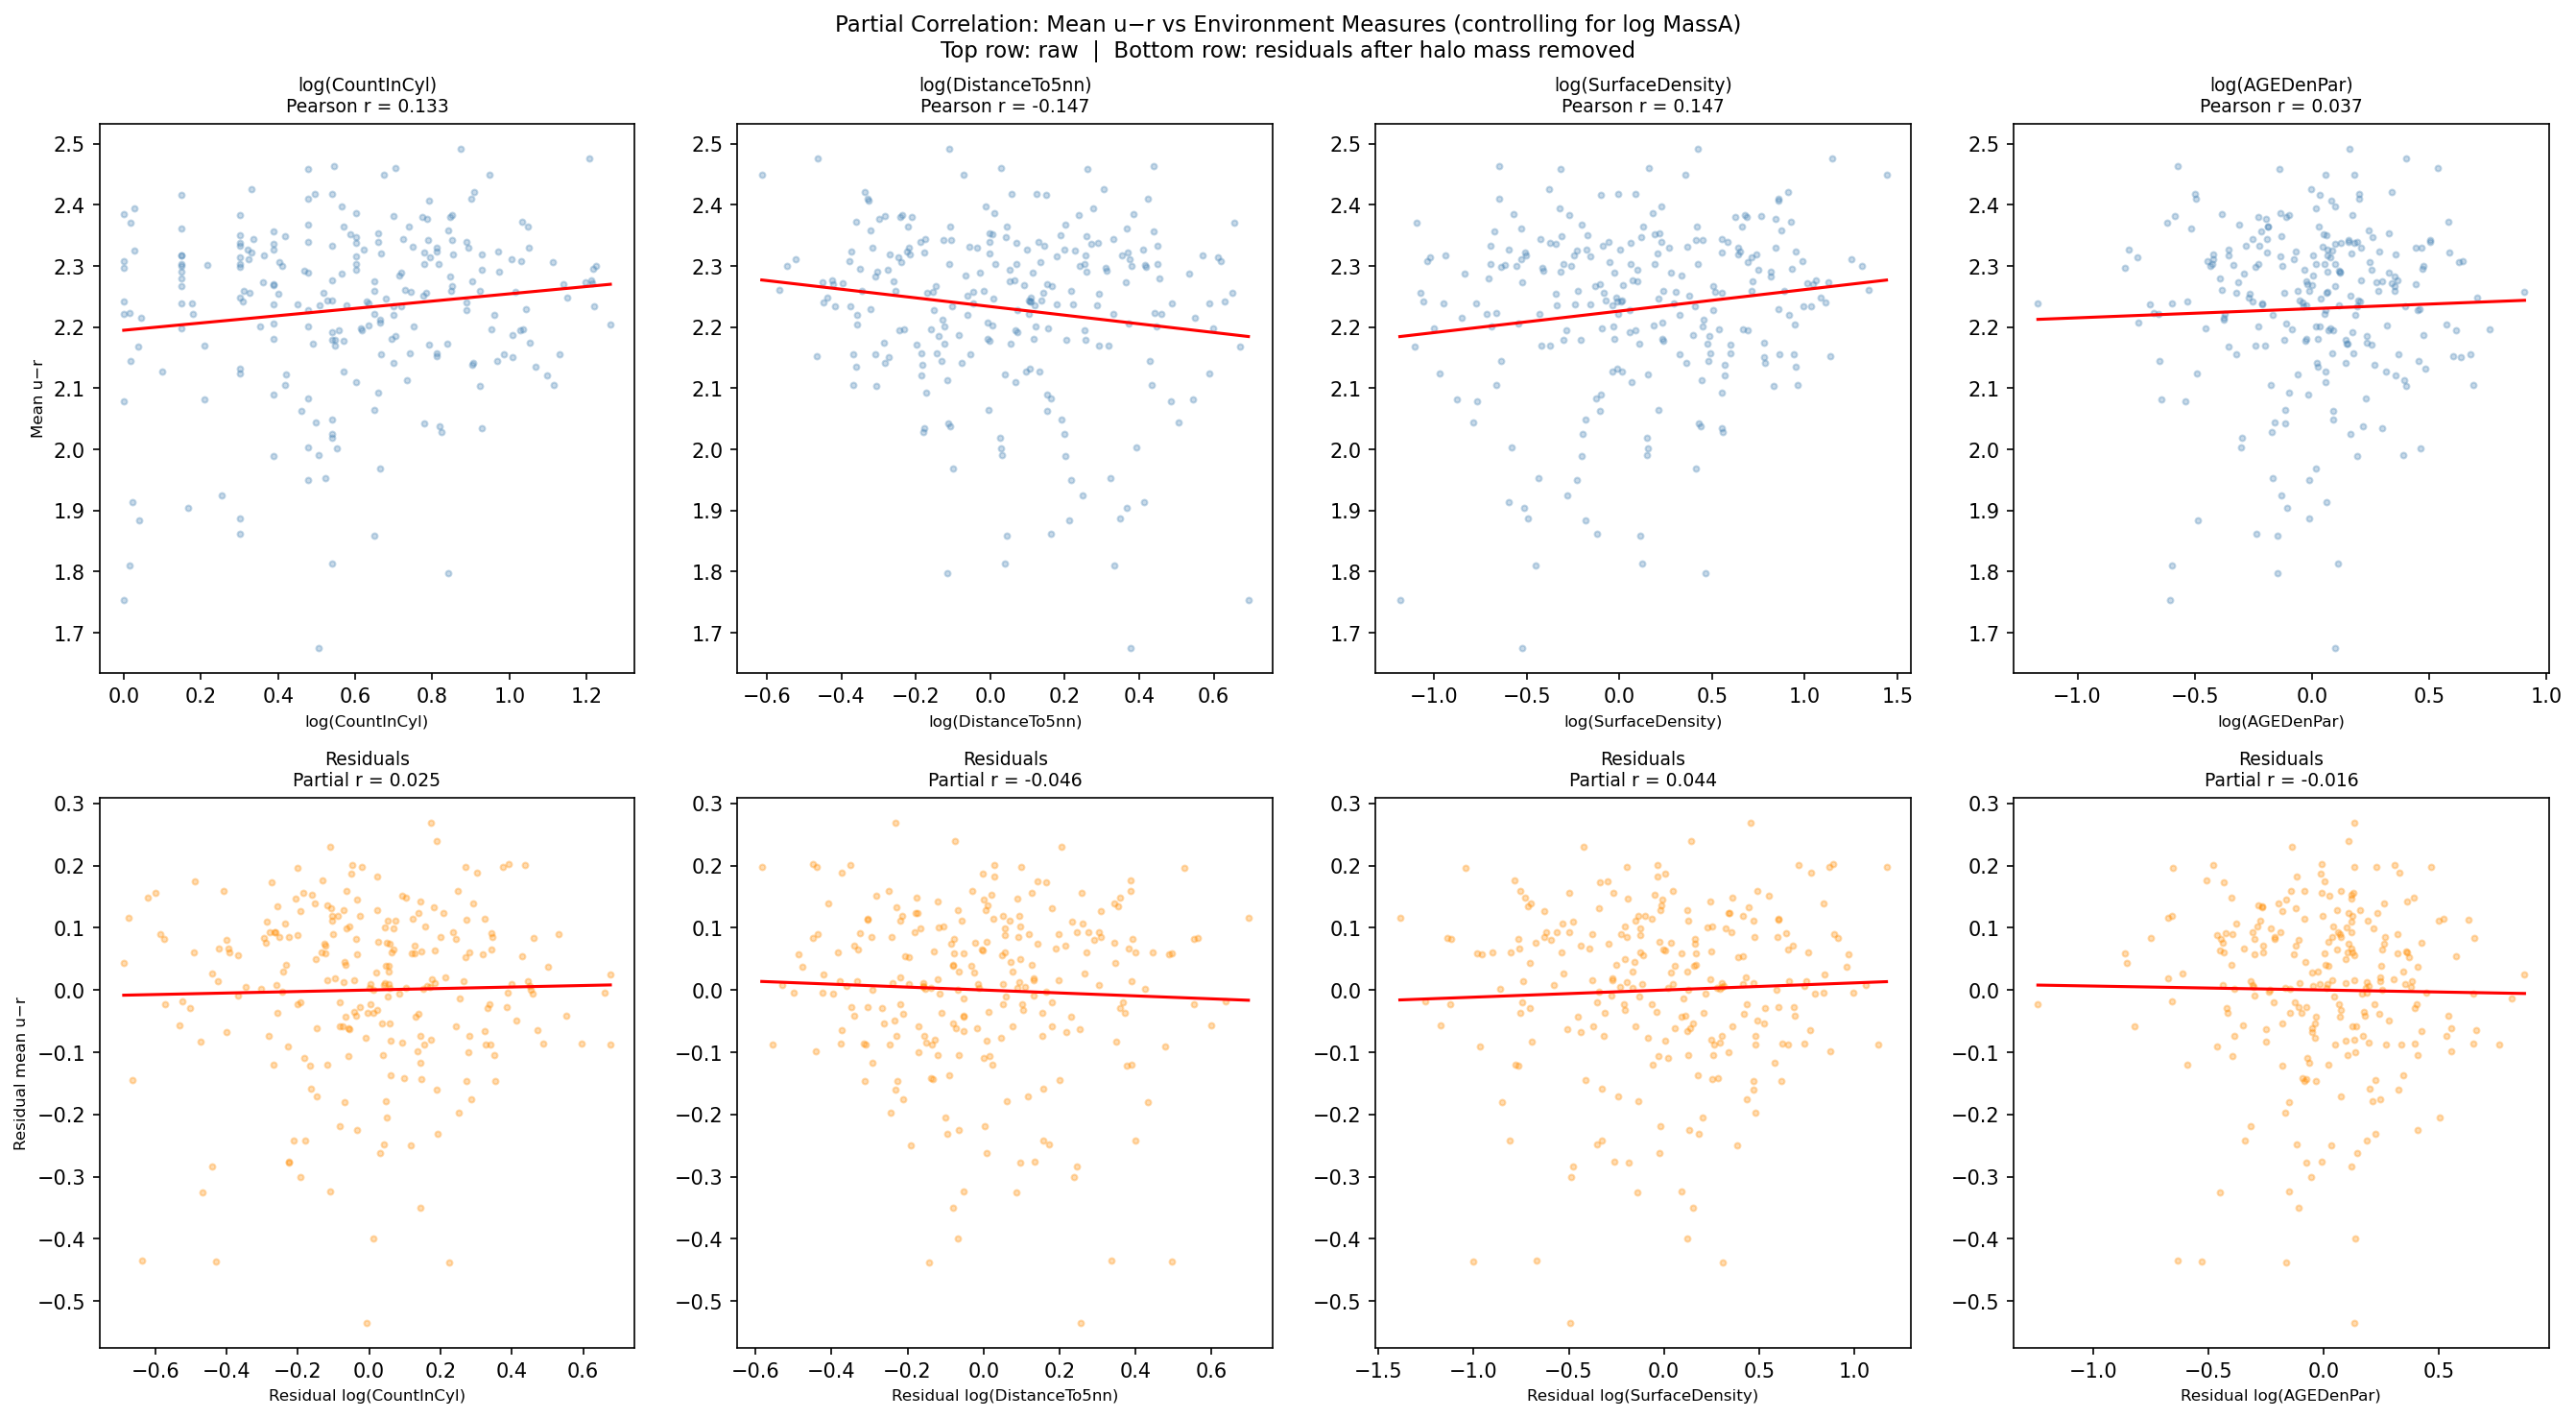

Figure saved to ChartsPlots/


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10), dpi=150)
fig.suptitle('Partial Correlation: Mean u−r vs Environment Measures (controlling for log MassA)\n'
             'Top row: raw  |  Bottom row: residuals after halo mass removed', fontsize=11)

env_labels = list(env_group_fields.keys())
env_arrays = list(env_group_fields.values())
res_ur = residualise(mean_ur, log_mass_g)

for col, (label, env) in enumerate(zip(env_labels, env_arrays)):
    res_env = residualise(env, log_mass_g)
    raw_r, _, _, _ = raw_corr(mean_ur, env)
    par_r, _, _, _ = partial_corr(mean_ur, env, log_mass_g)

    # Raw
    ax = axes[0, col]
    ax.scatter(env, mean_ur, alpha=0.3, s=8, color='steelblue')
    m, c, _, _, _ = stats.linregress(env, mean_ur)
    xr = np.linspace(env.min(), env.max(), 100)
    ax.plot(xr, m*xr+c, 'r-', lw=1.5)
    ax.set_title(f'{label}\nPearson r = {raw_r:.3f}', fontsize=9)
    ax.set_xlabel(label, fontsize=8)
    if col == 0: ax.set_ylabel('Mean u−r', fontsize=8)

    # Residuals
    ax2 = axes[1, col]
    ax2.scatter(res_env, res_ur, alpha=0.3, s=8, color='darkorange')
    m2, c2, _, _, _ = stats.linregress(res_env, res_ur)
    xr2 = np.linspace(res_env.min(), res_env.max(), 100)
    ax2.plot(xr2, m2*xr2+c2, 'r-', lw=1.5)
    ax2.set_title(f'Residuals\nPartial r = {par_r:.3f}', fontsize=9)
    ax2.set_xlabel(f'Residual {label}', fontsize=8)
    if col == 0: ax2.set_ylabel('Residual mean u−r', fontsize=8)

plt.tight_layout()
plt.savefig('../../ChartsPlots/PartialCorrelation_HaloMass_Group.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to ChartsPlots/')

## 6. Summary Table and Interpretation

In [8]:
print('=' * 90)
print('SUMMARY: Effect of controlling for halo mass (log10 MassA) on environment correlations')
print('=' * 90)

print('\n--- INDIVIDUAL GALAXY LEVEL (ellipticals in groups) ---')
print(f'{"Environment":<22} {"Raw r":>8} {"Partial r":>10} {"% change":>10} {"Sig after control?":>20}')
print('-' * 75)
for r in results_individual:
    pct = 100 * (r['partial_pearson'] - r['raw_pearson']) / abs(r['raw_pearson']) if r['raw_pearson'] != 0 else 0
    sig = 'Yes' if r['partial_p'] < 0.05 else 'No'
    print(f"{r['env']:<22} {r['raw_pearson']:>8.4f} {r['partial_pearson']:>10.4f} {pct:>+9.1f}% {sig:>20}")

print('\n--- GROUP LEVEL (mean per group, ellipticals only, N>=2) ---')
print(f'{"Environment":<22} {"Raw r":>8} {"Partial r":>10} {"% change":>10} {"Sig after control?":>20}')
print('-' * 75)
for r in results_group:
    pct = 100 * (r['partial_pearson'] - r['raw_pearson']) / abs(r['raw_pearson']) if r['raw_pearson'] != 0 else 0
    sig = 'Yes' if r['partial_p'] < 0.05 else 'No'
    print(f"{r['env']:<22} {r['raw_pearson']:>8.4f} {r['partial_pearson']:>10.4f} {pct:>+9.1f}% {sig:>20}")

print()
print('Interpretation guide:')
print('  If partial r << raw r  → halo mass explains most of the correlation')
print('  If partial r ~ raw r   → independent environment effect beyond halo mass')
print('  If partial r ~0 + insig → no residual environment signal')

SUMMARY: Effect of controlling for halo mass (log10 MassA) on environment correlations

--- INDIVIDUAL GALAXY LEVEL (ellipticals in groups) ---
Environment               Raw r  Partial r   % change   Sig after control?
---------------------------------------------------------------------------
log(CountInCyl)          0.0657    -0.0294    -144.7%                   No
log(DistanceTo5nn)      -0.0896    -0.0063     +93.0%                   No
log(SurfaceDensity)      0.0886     0.0046     -94.8%                   No
log(AGEDenPar)           0.0707     0.0225     -68.2%                   No

--- GROUP LEVEL (mean per group, ellipticals only, N>=2) ---
Environment               Raw r  Partial r   % change   Sig after control?
---------------------------------------------------------------------------
log(CountInCyl)          0.1329     0.0249     -81.3%                   No
log(DistanceTo5nn)      -0.1473    -0.0456     +69.1%                   No
log(SurfaceDensity)      0.1466     0.0444

## 7. Additional Check — TotRmag as Alternative Halo Mass Proxy

In [9]:
# TotRmag is brighter (more negative) for more massive groups
# Use -TotRmag so the proxy increases with group mass, for interpretability
totr_g = -group_df['TotRmag'].values  # flip sign: larger = brighter = more massive

print('=== GROUP LEVEL — controlling for TotRmag (alternative halo mass proxy) ===')
print(f'{"Environment":<22} {"Raw Pearson":>12} {"Partial Pearson":>16} {"Change":>8}')
print('-' * 65)

for label, env in env_group_fields.items():
    raw_pr, _, _, _ = raw_corr(mean_ur, env)
    par_pr, par_pp, _, _ = partial_corr(mean_ur, env, totr_g)
    change = par_pr - raw_pr
    print(f'{label:<22} {raw_pr:>12.4f} {par_pr:>16.4f} {change:>+8.4f}  p={par_pp:.3e}')

=== GROUP LEVEL — controlling for TotRmag (alternative halo mass proxy) ===
Environment             Raw Pearson  Partial Pearson   Change
-----------------------------------------------------------------
log(CountInCyl)              0.1329          -0.0947  -0.2276  p=1.418e-01
log(DistanceTo5nn)          -0.1473           0.0602  +0.2076  p=3.507e-01
log(SurfaceDensity)          0.1466          -0.0622  -0.2089  p=3.350e-01
log(AGEDenPar)               0.0365          -0.0877  -0.1243  p=1.736e-01
